# Autocorrelación espacial sobre la topología vial (nodos)

Prueba la hipótesis pendiente: si Moran's I ≈ 0 con adyacencia hexagonal
en todas las resoluciones probadas, ¿aparece autocorrelación real cuando
la vecindad se define por conectividad de calles (grafo vial) en vez de
proximidad euclidiana entre centroides de hexágono?

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import osmnx as ox
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point

import libpysal
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local
from splot.esda import moran_scatterplot

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

WINE = "#8B2635"
RED = "#C0392B"
ORANGE = "#E67E22"
GOLD = "#D4AC0D"
GRAY = "#7F8C8D"
DARK = "#34495E"


## 1. Datos y filtrado (idéntico al notebook de hexágonos)

In [28]:
def filtrar_dataset(df: pd.DataFrame, anio_inicio: int) -> pd.DataFrame:
    """
    Ventana temporal + filtros de calidad. Misma función que en el notebook
    de hexágonos -- debe usarse la MISMA ventana en ambos para que la
    comparación de Moran's I entre métodos sea válida.
    """
    mask = (
        (df['anio'] >= anio_inicio)
        & (df['coord_valida'] == True)
        & (df['es_duplicado_c5'] == False)
        & (df['target'] == 1)
    )
    return df.loc[mask].copy()


df = pd.read_csv('df_hour_clean.csv')

# NOTA: el notebook de hexágonos corrió con anio_inicio=2021, no 2022 (la
# ventana documentada como decisión). Confirma cuál usar antes de comparar
# resultados entre ambos métodos -- si difieren, el I no es comparable.
df_filtrado = filtrar_dataset(df, anio_inicio=2022)
print(f"Registros tras filtrado: {len(df_filtrado):,} de {len(df):,} originales "
      f"({len(df_filtrado) / len(df) * 100:.1f}%)")


Registros tras filtrado: 27,587 de 145,313 originales (19.0%)


## 2. Límite de Iztapalapa y red vial (OSMnx)

In [29]:
def obtener_limite_iztapalapa() -> gpd.GeoDataFrame:
    """Descarga el polígono administrativo de Iztapalapa vía OSMnx/Nominatim."""
    return ox.geocode_to_gdf("Iztapalapa, Ciudad de México, México")


def obtener_grafo_vial(gdf_limite: gpd.GeoDataFrame, network_type: str = 'drive') -> nx.MultiDiGraph:
    """
    Descarga la red vial de Iztapalapa. network_type='drive' porque el
    fenómeno (siniestros viales) es vehicular -- no tiene sentido incluir
    andadores peatonales en la topología de propagación del riesgo.
    Nombre de función puede variar entre versiones de OSMnx
    (graph_from_polygon); ajusta si tu versión difiere.
    """
    return ox.graph_from_polygon(gdf_limite.geometry.unary_union, network_type=network_type, simplify=True)


iztapalapa_gdf = obtener_limite_iztapalapa()
G_vial = obtener_grafo_vial(iztapalapa_gdf)
print(f"Nodos: {G_vial.number_of_nodes():,} | Aristas: {G_vial.number_of_edges():,}")


C:\Users\jesus\AppData\Local\Temp\ipykernel_21100\2918348470.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return ox.graph_from_polygon(gdf_limite.geometry.unary_union, network_type=network_type, simplify=True)


Nodos: 22,875 | Aristas: 58,112


## 3. Asignación de incidentes a nodos y agregación

In [30]:
def asignar_nodo_vial(df: pd.DataFrame, G: nx.MultiDiGraph) -> pd.DataFrame:
    """
    Asigna a cada incidente el nodo (intersección) más cercano de la red
    vial. Equivalente, para la topología de calles, de asignar_celda_h3
    para la malla hexagonal.
    """
    df = df.copy()
    df['nodo_id'] = ox.distance.nearest_nodes(G, X=df['longitud'].values, Y=df['latitud'].values)
    return df


def construir_gdf_nodos(G: nx.MultiDiGraph, df: pd.DataFrame) -> gpd.GeoDataFrame:
    """
    Un punto por cada intersección de la red vial (incluye nodos sin
    incidentes) con su conteo total. Igual que con H3: se necesita la
    malla completa, no solo los nodos con incidentes, para que la matriz
    de vecinos quede completa.
    """
    conteo = df.groupby('nodo_id').size().rename('conteo_incidentes')

    nodos = pd.DataFrame({'nodo_id': list(G.nodes())}).set_index('nodo_id')
    nodos = nodos.join(conteo).fillna(0)
    nodos['conteo_incidentes'] = nodos['conteo_incidentes'].astype(int)
    nodos = nodos.reset_index()

    coords = {n: (d['x'], d['y']) for n, d in G.nodes(data=True)}
    nodos['geometry'] = nodos['nodo_id'].map(lambda n: Point(coords[n]))

    return gpd.GeoDataFrame(nodos, geometry='geometry', crs='EPSG:4326')


df_filtrado = asignar_nodo_vial(df_filtrado, G_vial) 
gdf_nodos = construir_gdf_nodos(G_vial, df_filtrado)

print(f"Nodos totales: {len(gdf_nodos)}")
print(f"Nodos con al menos un incidente: {(gdf_nodos['conteo_incidentes'] > 0).sum()}")


Nodos totales: 22875
Nodos con al menos un incidente: 7147


## 4. Matriz de pesos espaciales (adyacencia real de la red vial)

In [31]:
def construir_pesos_grafo(G: nx.MultiDiGraph, nodo_ids: list) -> "libpysal.weights.W":
    """
    Dos nodos son vecinos si existe un segmento de calle que los conecta
    directamente -- no por cercanía geométrica. Se usa el grafo no
    dirigido: una calle conecta en ambos sentidos para fines de
    autocorrelación espacial (el sentido de circulación no aplica aquí).
    """
    G_ud = G.to_undirected()
    vecinos = {n: list(G_ud.neighbors(n)) for n in nodo_ids}

    w = libpysal.weights.W(vecinos)
    w.transform = 'r'

    if w.islands:
        print(f"Nodos aislados (sin vecinos en el grafo): {len(w.islands)}")

    return w


w_nodos = construir_pesos_grafo(G_vial, gdf_nodos['nodo_id'].tolist())


## 5. Pruebas de autocorrelación espacial

Mismas tres funciones del notebook de hexágonos (`permutations=999`,
inferencia por permutación -- sigue aplicando el mismo argumento de
zero-inflation). Con más nodos que hexágonos, esta celda puede tardar más;
si es muy lento, agrega `n_jobs=-1` dentro de `Moran_Local`/`G_Local`.

In [32]:
def prueba_moran_global(y: np.ndarray, w: "libpysal.weights.W", permutaciones: int = 999) -> Moran:
    """Moran's I global: ¿existe autocorrelación espacial en general?"""
    moran = Moran(y, w, permutations=permutaciones)
    print(f"Moran's I global : {moran.I:.4f}")
    print(f"p-value (sim)    : {moran.p_sim:.4f}")
    print(f"z-score (sim)    : {moran.z_sim:.4f}")
    return moran


In [33]:
def prueba_lisa(y: np.ndarray, w: "libpysal.weights.W", permutaciones: int = 999) -> Moran_Local:
    """Local Moran's I (LISA): clusters HH/LL y outliers HL/LH por nodo."""
    return Moran_Local(y, w, permutations=permutaciones, seed=42)


In [34]:
def prueba_getis_ord(y: np.ndarray, w: "libpysal.weights.W", permutaciones: int = 999) -> G_Local:
    """Getis-Ord Gi*: hot spots / cold spots estadísticamente significativos."""
    return G_Local(y, w, star=True, permutations=permutaciones, seed=42)


In [35]:
y_nodos = gdf_nodos['conteo_incidentes'].values.astype(float)

moran_nodos = prueba_moran_global(y_nodos, w_nodos)
lisa_nodos = prueba_lisa(y_nodos, w_nodos)
gi_nodos = prueba_getis_ord(y_nodos, w_nodos)

gdf_nodos['lisa_cuadrante'] = lisa_nodos.q      # 1=HH, 2=LH, 3=LL, 4=HL
gdf_nodos['lisa_p'] = lisa_nodos.p_sim
gdf_nodos['gi_z'] = gi_nodos.Zs
gdf_nodos['gi_p'] = gi_nodos.p_sim


Moran's I global : 0.3120
p-value (sim)    : 0.0010
z-score (sim)    : 51.7345


d:\Lic Ciencia de Datos\TT C5\venv\Lib\site-packages\esda\getisord.py:362: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


## 6. Visualizaciones

d:\Lic Ciencia de Datos\TT C5\venv\Lib\site-packages\spreg\diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)


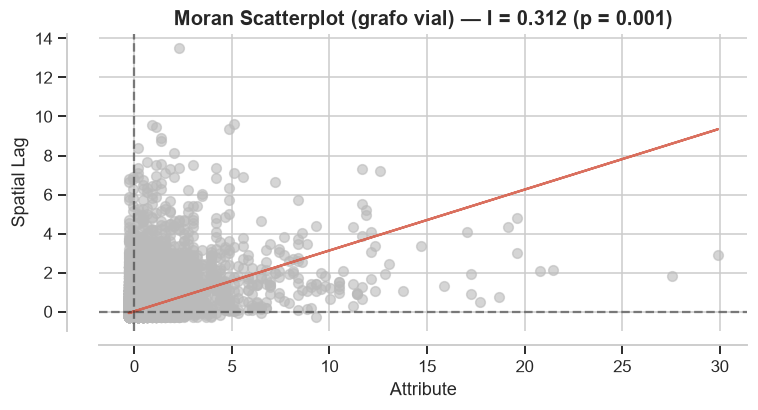

In [36]:
fig, ax = moran_scatterplot(moran_nodos, aspect_equal=True)
ax.set_title(f"Moran Scatterplot (grafo vial) — I = {moran_nodos.I:.3f} (p = {moran_nodos.p_sim:.3f})")
plt.tight_layout()
plt.show()


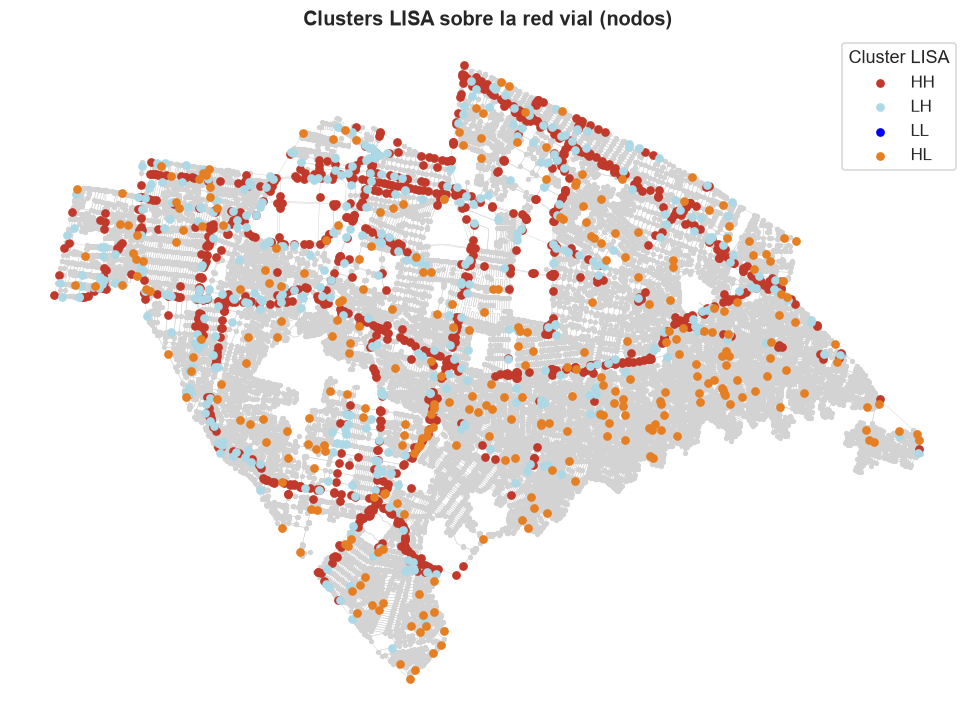

In [37]:
def mapa_lisa_nodos(gdf: gpd.GeoDataFrame, G: nx.MultiDiGraph, p: float = 0.05):
    """Clusters LISA sobre la red vial: nodos coloreados por cuadrante, calles de fondo."""
    _, edges = ox.graph_to_gdfs(G)
    colores = {1: RED, 2: 'lightblue', 3: 'blue', 4: ORANGE}
    etiquetas = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}

    fig, ax = plt.subplots(figsize=(9, 9))
    edges.plot(ax=ax, color='lightgrey', linewidth=0.3, zorder=1)

    no_sig = gdf[gdf['lisa_p'] >= p]
    ax.scatter(no_sig.geometry.x, no_sig.geometry.y, color='lightgrey', s=6, zorder=2)

    for q, color in colores.items():
        sub = gdf[(gdf['lisa_p'] < p) & (gdf['lisa_cuadrante'] == q)]
        ax.scatter(sub.geometry.x, sub.geometry.y, color=color, s=22, label=etiquetas[q], zorder=3)

    ax.legend(title='Cluster LISA')
    ax.set_title('Clusters LISA sobre la red vial (nodos)')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


mapa_lisa_nodos(gdf_nodos, G_vial)


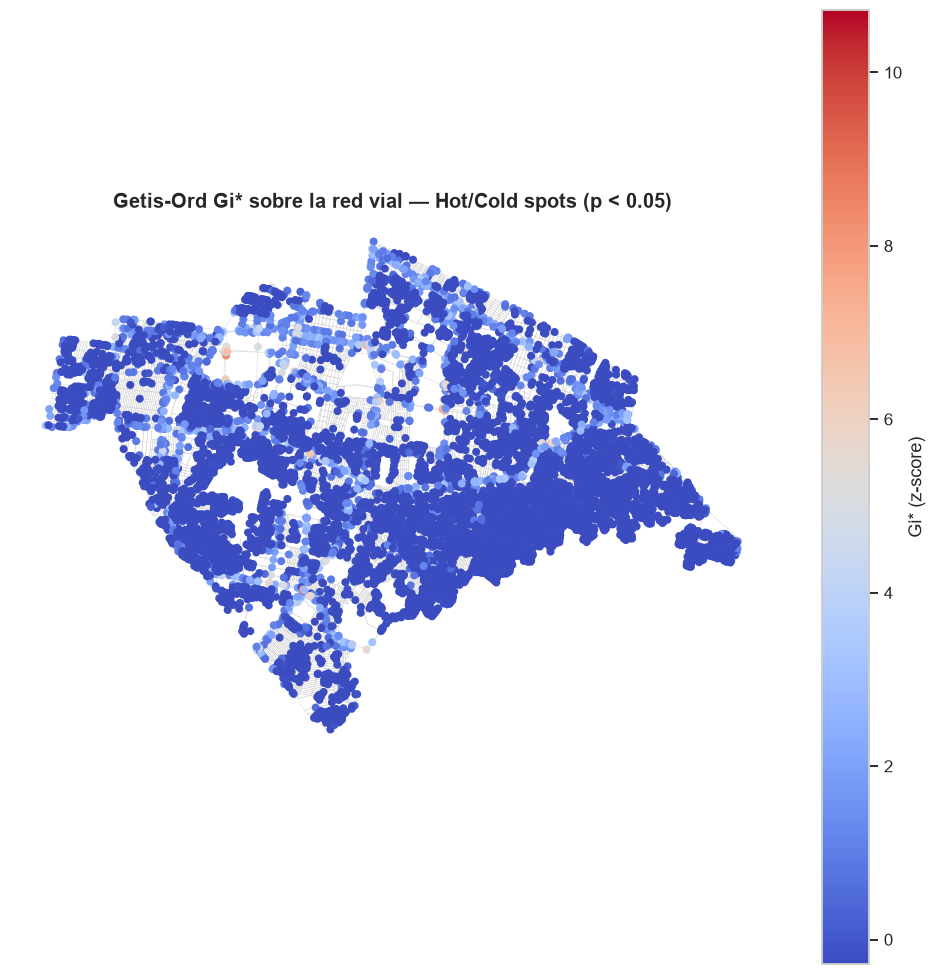

In [38]:
def mapa_hotspots_gi_nodos(gdf: gpd.GeoDataFrame, G: nx.MultiDiGraph, alpha: float = 0.05):
    """Hot/cold spots (Gi*) sobre la red vial, mostrando solo nodos significativos."""
    _, edges = ox.graph_to_gdfs(G)

    fig, ax = plt.subplots(figsize=(9, 9))
    edges.plot(ax=ax, color='lightgrey', linewidth=0.3, zorder=1)

    gdf_plot = gdf.copy()
    gdf_plot.loc[gdf_plot['gi_p'] >= alpha, 'gi_z'] = np.nan

    sc = ax.scatter(
        gdf_plot.geometry.x, gdf_plot.geometry.y,
        c=gdf_plot['gi_z'], cmap='coolwarm', s=18, zorder=2,
    )
    plt.colorbar(sc, ax=ax, label='Gi* (z-score)')
    ax.set_title(f'Getis-Ord Gi* sobre la red vial — Hot/Cold spots (p < {alpha})')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


mapa_hotspots_gi_nodos(gdf_nodos, G_vial)


## 7. Resumen comparativo

In [39]:
resumen_grafo_vial = pd.DataFrame([{
    'metodo': 'grafo_vial (nodos)',
    'n_celdas': len(gdf_nodos),
    'celdas_con_incidentes': int((gdf_nodos['conteo_incidentes'] > 0).sum()),
    'celdas_aisladas': len(w_nodos.islands),
    'moran_I': moran_nodos.I,
    'moran_p_sim': moran_nodos.p_sim,
    'moran_z_sim': moran_nodos.z_sim,
    'gi_significativas_p05': int((gdf_nodos['gi_p'] < 0.05).sum()),
}])
resumen_grafo_vial

# Para comparar contra la tabla de resoluciones H3 (mismas columnas):
# pd.concat(
#     [resumen_resoluciones.rename(columns={'resolucion': 'metodo'}), resumen_grafo_vial],
#     ignore_index=True,
# )


,metodo,n_celdas,celdas_con_incidentes,celdas_aisladas,moran_I,moran_p_sim,moran_z_sim,gi_significativas_p05
0,grafo_vial (nodos),22875,7147,0,0.312021,0.001,51.734456,10935


Moran's I global : 0.4476
p-value (sim)    : 0.0010
z-score (sim)    : 74.5296


d:\Lic Ciencia de Datos\TT C5\venv\Lib\site-packages\spreg\diagnostics.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  ci_result = sqrt(max_eigval / min_eigval)


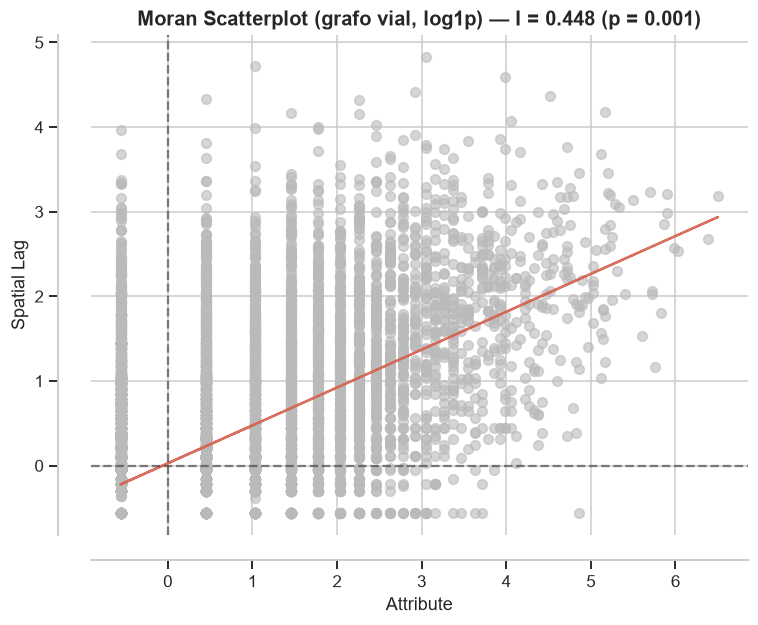

In [40]:
y_nodos_log = np.log1p(gdf_nodos['conteo_incidentes'].values)

moran_nodos_log = prueba_moran_global(y_nodos_log, w_nodos)

fig, ax = moran_scatterplot(moran_nodos_log, aspect_equal=True)
ax.set_title(f"Moran Scatterplot (grafo vial, log1p) — I = {moran_nodos_log.I:.3f} (p = {moran_nodos_log.p_sim:.3f})")
plt.tight_layout()
plt.show()